In [1]:
# Downloading the dataset from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("openfoodfacts/world-food-facts")

print("Path to dataset files:", path)

c:\Coding\Projects\MLOps\Major_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Sidhartg\.cache\kagglehub\datasets\openfoodfacts\world-food-facts\versions\5


In [2]:
# Loading Open food facts dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)

data_path = 'data/raw/en.openfoodfacts.org.products.tsv'

try:
    OFF_df = pd.read_csv(data_path, sep='\t', low_memory=False)
    print(f"Dataset loaded successfully with {OFF_df.shape[0]} rows and {OFF_df.shape[1]} columns...")

except FileNotFoundError as e:
    print("File not found at given path!!!")
    exit

Dataset loaded successfully with 356027 rows and 163 columns...


In [3]:
# Analyzing OFF dataset
# OFF_df.head()
OFF_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356027 entries, 0 to 356026
Columns: 163 entries, code to water-hardness_100g
dtypes: float64(107), object(56)
memory usage: 442.8+ MB


In [4]:
miss_val_count = OFF_df.isnull().sum()
print(miss_val_count.sort_values(ascending=False).head(20))

ingredients_from_palm_oil                356027
ingredients_that_may_be_from_palm_oil    356027
no_nutriments                            356027
chlorophyl_100g                          356027
water-hardness_100g                      356027
glycemic-index_100g                      356027
-butyric-acid_100g                       356027
-melissic-acid_100g                      356027
-nervonic-acid_100g                      356027
-erucic-acid_100g                        356027
-mead-acid_100g                          356027
-elaidic-acid_100g                       356027
-caproic-acid_100g                       356027
-lignoceric-acid_100g                    356027
-cerotic-acid_100g                       356027
nutrition_grade_uk                       356027
-montanic-acid_100g                      356026
-palmitic-acid_100g                      356026
-stearic-acid_100g                       356026
-caprylic-acid_100g                      356026
dtype: int64


In [5]:
# No of missing cols in main columns that we care of
main_cols = ['nutrition-score-fr_100g', 'product_name', 'main_category_en', 'ingredients_text']
print(miss_val_count[main_cols])

nutrition-score-fr_100g    101171
product_name                17512
main_category_en           252778
ingredients_text            72134
dtype: int64


In [6]:
# Examining ingredients_text column
print("Creating smple ingredient to check...")

sample_ing_list = OFF_df['ingredients_text'].dropna().sample(5).tolist()
for i, ingredients in enumerate(sample_ing_list):
    print(f"Sample {i+1}: {ingredients[:250]}...")

Creating smple ingredient to check...
Sample 1: Sirop de glucose, sucre, gélatine de proc, acidifiants (acide citrique, acide malique), correcteur d'acidité (malates de sodium), arômes naturels (arôme naturel d'orange, arôme naturel de citron avec autres arômes naturels, arôme naturel de pomme ave...
Sample 2: Monterey jack cheese (pasteurized milk, cheese cultures, salt, enzymes)....
Sample 3: riz parboiled cuit 28 %, produit à base de viande de poulet 22 % [viande de poitrine de poulet 83 %, eau, huile de colza, sel de cuisine iodé, maltodextrine, condiment, fécule de pommes de terre, épices], légumes 18 % (courgettes 44 %, poivrons 29 %,...
Sample 4: Pork, water, salt, spices, sugar...
Sample 5: Peanuts, contains 2% or less of: sea salt, torula yeast, modified food starch, maltodextrin, natural flavor, paprika, spices, garlic and onion powders, oleoresin of paprika....


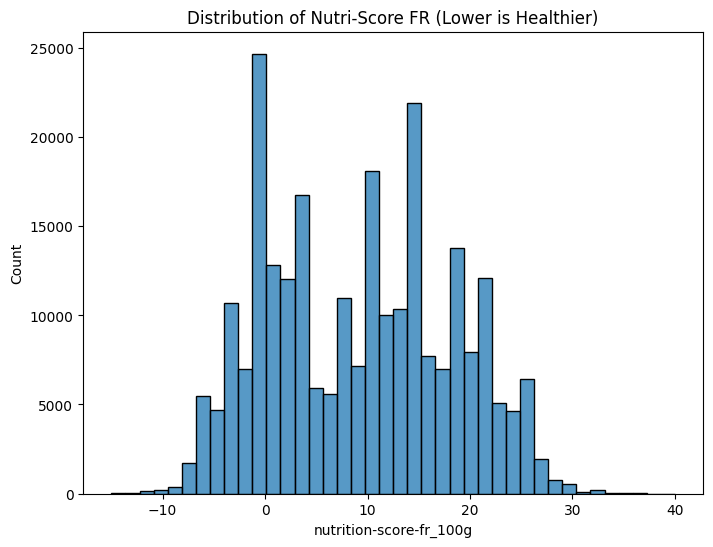

In [7]:
# Examining distribution of nutrition-score-fr_100g
plt.figure(figsize=(8, 6))
sns.histplot(OFF_df['nutrition-score-fr_100g'].dropna(), bins=40, kde=False)
plt.title('Distribution of Nutri-Score FR (Lower is Healthier)')
plt.show()

In [8]:
# Most common food categories
print(OFF_df['main_category_en'].value_counts().head(20))

main_category_en
Plant-based foods and beverages    22950
Beverages                          14205
Sugary snacks                      12740
Dairies                             8086
Groceries                           6478
Meats                               5397
Fresh foods                         3562
Meals                               3005
Spreads                             2445
Salty snacks                        2384
Fruit juices                        2383
Canned foods                        1944
Frozen foods                        1715
Seafood                             1696
Desserts                            1383
Fats                                 772
Sandwiches                           728
Sweeteners                           628
Farming products                     568
Baby foods                           567
Name: count, dtype: int64


In [9]:
# Removing null values in main columns
main_cols = ['nutrition-score-fr_100g', 'product_name', 'main_category_en', 'ingredients_text']
print(f"Original dataset with {len(OFF_df)} rows")

mod_df = OFF_df.dropna(subset=main_cols)

print(f"Modified dataset with {len(mod_df)} rows")

Original dataset with 356027 rows
Modified dataset with 67492 rows


In [10]:
# Downloading food-101 datset from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/food-101")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Sidhartg\.cache\kagglehub\datasets\dansbecker\food-101\versions\1


In [11]:
# Loading and creating train and test dataset for food-101
import tensorflow as tf

data_dir = r"C:\Users\Sidhartg\.cache\kagglehub\datasets\dansbecker\food-101\versions\1\food-101\food-101\images"

img_size = (224, 224)
batch__size = 32

print("\nCreating train and validation dataset from image folders...")

ds_train = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir,
    labels='inferred',
    label_mode='int',
    image_size=img_size,
    batch_size=batch__size,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training'
)

ds_valid = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir,
    labels='inferred',
    label_mode='int',
    image_size=img_size,
    batch_size=batch__size,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='validation'
)

class_names = ds_train.class_names
print(f"\nFound {len(class_names)} classes.")
print("First 10 classes:", class_names[:10])


Creating train and validation dataset from image folders...
Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.

Found 101 classes.
First 10 classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [12]:
# Tried linking the datasets using substring method but did'nt work!!
# food_101_labels = [label.replace('_', ' ') for label in class_names] # Removing underscores in food101 labels

# print("Linking both the datasets...")

# mod_df['food_101_label'] = None

# for label in food_101_labels: # Using substrings method to link the subsets
#     mask = mod_df['main_category_en'].str.contains(label, case=False, na=False)
#     mod_df.loc[mask, 'food_101_label'] = label

# golden_df = mod_df.dropna(subset=['food_101_label'])

# print("Completed Linking!!")

In [13]:
# print("Shape of the final 'golden' dataset:", golden_df.shape)

# display(golden_df[['product_name', 'main_category_en', 'food_101_label']].sample(15))

# print("\n--- Top 20 Most Linked Categories ---")
# print(golden_df['food_101_label'].value_counts().head(20)) # This cannot be used cause all of the count in food_101_label are low

In [14]:
# image_df = mod_df.dropna(subset=['image_url'])
# print(f"Found {len(image_df)} products with an image URL.")

# health_limit = 10

# image_df['health_label'] = image_df['nutrition-score-fr_100g'].apply(lambda score: 1 if score > health_limit else 0)
# print(image_df['health_label'].value_counts())

In [15]:
# final_vision_ds = image_df[['image_url', 'health_label']].copy()

# print(f"\nCreated final dataset for vision task with {len(final_vision_ds)} images.")
# print("\n--- Example Rows from the Final Vision Dataset ---")
# display(final_vision_ds.sample(10))

In [16]:
from sentence_transformers import SentenceTransformer

food_101_labels = [label.replace('_', ' ') for label in class_names] # Removing underscores in food101 labels

unique_off_categories = mod_df['main_category_en'].dropna().unique().tolist()

model = SentenceTransformer(model_name_or_path='all-MiniLM-L6-v2')

f101_embeddings = model.encode(food_101_labels, show_progress_bar=True)
OFF_embeddings = model.encode(unique_off_categories, show_progress_bar=True)

Batches: 100%|██████████| 59/59 [00:02<00:00, 28.05it/s]


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(OFF_embeddings, f101_embeddings)

best_match_indices = np.argmax(sim_matrix, axis=1)
best_match_scores = np.max(sim_matrix, axis=1)

sim_threshold = 0.6 # Minimum percent or limit for similarity to accept

category_mapping = {}
for i, off_category in enumerate(unique_off_categories):
    if best_match_scores[i] > sim_threshold:
        matched_food101_label = food_101_labels[best_match_indices[i]]
        category_mapping[off_category] = matched_food101_label

In [18]:
mod_df['food_101_label'] = mod_df['main_category_en'].map(category_mapping)

golden2_df = mod_df.dropna(subset=['food_101_label'])
print(f"\nSuccessfully linked {len(golden2_df)} products using semantic search!")

C:\Users\Sidhartg\AppData\Local\Temp\ipykernel_51100\2075838944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_df['food_101_label'] = mod_df['main_category_en'].map(category_mapping)



Successfully linked 9195 products using semantic search!


In [19]:
# Analyzing the new result
print("\nShape of the new 'golden' dataset:", golden2_df.shape)

print("\n--- Top 20 Most Linked Categories (Semantic Search) ---")
print(golden2_df['food_101_label'].value_counts().head(20))

print("\n--- Example Rows from the new Golden Dataset ---")
display(golden2_df[['product_name', 'main_category_en', 'food_101_label']].sample(10))


Shape of the new 'golden' dataset: (9195, 164)

--- Top 20 Most Linked Categories (Semantic Search) ---
food_101_label
steak               3667
frozen yogurt       1444
oysters             1138
chocolate cake      1082
club sandwich        620
pancakes             301
apple pie            234
fish and chips       228
waffles              213
pizza                 45
gnocchi               22
caprese salad         17
caesar salad          15
chocolate mousse      13
beet salad            12
creme brulee          11
beignets              10
dumplings             10
beef tartare           8
garlic bread           7
Name: count, dtype: int64

--- Example Rows from the new Golden Dataset ---


,product_name,main_category_en,food_101_label
235458,Saucisse de Francfort 100% pur porc - fumé au ...,Meats,steak
355079,Seafood Dumplings,Frozen-dumpling,dumplings
194460,Saumon sauvage,Seafood,oysters
200512,Bloc de Foie Gras de Canard au Sel de Guérande,Fish and meat and eggs,fish and chips
263746,Panés de Dinde,Meats,steak
199277,Le supérieur - 25% de sel* - 8 tranches,Meats,steak
183285,Chorizo Pizza,Frozen foods,frozen yogurt
230106,Gaufres fines pur beurre à la Chicorée,Waffles,waffles
231131,2 coupes glacées Limoncello,Desserts,chocolate cake
205218,Bacon Burger,Sandwiches,club sandwich


In [20]:
samples_per_cls = 200

def balance_datset(df):
    print(f"Balancing dataset to have at most {samples_per_cls} samples per class...")

    balanced_df = df.groupby('food_101_label').sample(n=samples_per_cls, random_state=42, replace=True)
    return balanced_df.reset_index(drop=True)

balanced_df = balance_datset(golden2_df)

print(balanced_df['food_101_label'].value_counts())
print(f"\nTotal size of balanced dataset: {len(balanced_df)} rows")

Balancing dataset to have at most 200 samples per class...
food_101_label
apple pie              200
baklava                200
beef carpaccio         200
beef tartare           200
beet salad             200
beignets               200
bread pudding          200
breakfast burrito      200
bruschetta             200
caesar salad           200
caprese salad          200
carrot cake            200
chicken curry          200
chicken quesadilla     200
chicken wings          200
chocolate cake         200
chocolate mousse       200
club sandwich          200
crab cakes             200
creme brulee           200
croque madame          200
donuts                 200
dumplings              200
eggs benedict          200
fish and chips         200
foie gras              200
french onion soup      200
french toast           200
fried rice             200
frozen yogurt          200
garlic bread           200
gnocchi                200
greek salad            200
guacamole              200
hamburge

In [21]:
import os
import pandas as pd

food101_dir = r"C:\Users\Sidhartg\.cache\kagglehub\datasets\dansbecker\food-101\versions\1\food-101\food-101\images"

filepaths = []
labels = []

print(f"Scanning for images in given path...")
for dirpath, dirnames, filenames in os.walk(food101_dir):
    for filename in filenames:
        if filename.endswith(".jpg"):
            image_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            
            filepaths.append(image_path)
            labels.append(label)

image_path_df = pd.DataFrame({
    'filepath': filepaths,
    'food_101_label': labels
})
image_path_df['food_101_label'] = image_path_df['food_101_label'].str.replace('_', ' ')

print(f"\nFound {len(image_path_df)} images in the Food-101 directory.")
display(image_path_df.sample(5))

Scanning for images in given path...

Found 101000 images in the Food-101 directory.


,filepath,food_101_label
82437,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,ravioli
45009,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,frozen yogurt
77186,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,pork chop
36872,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,falafel
27409,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,creme brulee


In [22]:
print("Original golden_df shape:", balanced_df.shape)
print("Image path DataFrame shape:", image_path_df.shape)

# Before merging we have to sample the impage_path_df
# final_df = pd.merge(golden2_df, image_path_df, on='food_101_label')

# print(f"\nShape of final merged dataset: {final_df.shape}")
# display(final_df[['product_name', 'food_101_label', 'filepath', 'ingredients_text']].sample(5))

SAMPLES_PER_CLS =200

sampled_image_path_df = image_path_df.groupby('food_101_label').apply(lambda x: x.sample(n=min(len(x), SAMPLES_PER_CLS), random_state=42, replace=True)).reset_index(drop=True)

print("\nShape of *sampled* image paths DataFrame:", sampled_image_path_df.shape)
# final_df = pd.merge(balanced_df, sampled_image_path_df, on='food_101_label') # Not working getting errors

# print(f"\nShape of final merged dataset: {final_df.shape}")
# display(final_df[['product_name', 'food_101_label', 'filepath', 'ingredients_text']].sample(5))

balanced_df.sort_values('food_101_label', inplace=True)
sampled_image_path_df.sort_values('food_101_label', inplace=True)

final_train_df = balanced_df.copy()
final_train_df['filepath'] = sampled_image_path_df['filepath']

print(f"Shape of final training data: {final_train_df.shape}")
display(final_train_df[['product_name', 'food_101_label', 'filepath', 'ingredients_text']].sample(5))

Original golden_df shape: (12000, 164)
Image path DataFrame shape: (101000, 2)

Shape of *sampled* image paths DataFrame: (20200, 2)
Shape of final training data: (12000, 165)


C:\Users\Sidhartg\AppData\Local\Temp\ipykernel_51100\1916349536.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_image_path_df = image_path_df.groupby('food_101_label').apply(lambda x: x.sample(n=min(len(x), SAMPLES_PER_CLS), random_state=42, replace=True)).reset_index(drop=True)


,product_name,food_101_label,filepath,ingredients_text
1126,Beignets chocolat noisette,beignets,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,ngrédients : Farine de blé (gluten) • Huiles v...
1662,Crostino dorato,bruschetta,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,"Farina di FRUMENTO, olio vegetale, lievito, sa..."
9381,British pork lean mince,pork chop,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,Pork
3035,Glace au caramel d'Isigny au beurre salé avec ...,chocolate cake,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,"_LAIT_ entier, jaune d'_ŒUF_, 11% caramel d'Is..."
5455,Tostadas Integrales,french toast,C:\Users\Sidhartg\.cache\kagglehub\datasets\da...,"Farinha integral de _trigo_ (51%), farinha de ..."


In [23]:
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

labels = final_train_df['food_101_label'].unique().tolist()
label_id = {label: i for i,label in enumerate(labels)}
id_label = {i: label for i,label in enumerate(labels)}

final_train_df['label'] = final_train_df['food_101_label'].map(label_id)

train_df, test_df = train_test_split(final_train_df, test_size=0.2, random_state=42, stratify=final_train_df['label'])

train_data = Dataset.from_pandas(train_df.reset_index(drop=True))
test_data = Dataset.from_pandas(test_df.reset_index(drop=True))

print("Train data: ")
print(train_data)

Train data: 
Dataset({
    features: ['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'brands', 'brands_tags', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'no_nutriments', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'ingredients_from_palm_oil_n', 'ingredients_from_palm_oil', 'ingredients_from_palm_oil_tags', 'ingredients_that_may_be_from_palm_oil_n', 'ingredients_that_may_be_from_palm_oil', 'ingredients_that_may_be_from_palm_oil_tags', 'nutrition_grade_uk', 'n

In [24]:
from transformers import AutoImageProcessor

model_name = "google/vit-base-patch16-224-in21k"
img_processor = AutoImageProcessor.from_pretrained(model_name)

In [25]:
from PIL import Image

def transform_img(ex):
    img_list = [Image.open(fp).convert("RGB") for fp in ex['filepath']]
    inputs = img_processor(img_list, return_tensors='pt')
    inputs['label'] = ex['label']
    return inputs

In [26]:
from transformers import AutoModelForImageClassification

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label = id_label,
    label2id = label_id,
    ignore_mismatched_sizes=True
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
from transformers import TrainingArguments, Trainer
import evaluate

train_arg = TrainingArguments(
    output_dir="Food_Vision_Model",
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

metric = evaluate.load("accuracy")
def metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=-1)
    return metric.compute(predictions=pred, references=labels)

trainer = Trainer(
    model=model,
    args=train_arg,
    train_dataset=train_data.with_transform(transform_img),
    eval_dataset=test_data.with_transform(transform_img),
    tokenizer=img_processor,
    compute_metrics=metrics
)

print("Starting Vision Transformer fine-tuning...")
trainer.train()

C:\Users\Sidhartg\AppData\Local\Temp\ipykernel_51100\421458566.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting Vision Transformer fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,2.071700,1.993480,0.798333
2,1.030500,1.251938,0.843333
3,0.654400,1.044974,0.847083


TrainOutput(global_step=1800, training_loss=1.5871246820025975, metrics={'train_runtime': 7813.2619, 'train_samples_per_second': 3.686, 'train_steps_per_second': 0.23, 'total_flos': 2.2329294541553664e+18, 'train_loss': 1.5871246820025975, 'epoch': 3.0})

In [29]:
allergy_list = [
    'milk', 'lactose',
    'egg', 'eggs',
    'fish',
    'shellfish', 'crustacean', 'shrimp', 'crab', 'lobster', 'prawn',
    'tree nut', 'tree nuts', 'almond', 'walnut', 'pecan', 'cashew', 'pistachio', 'hazelnut',
    'peanut', 'peanuts',
    'wheat', 'gluten',
    'soy', 'soybean', 'soya',
    'sesame',
    'mustard',
    'celery',
    'sulphites', 'sulfites'
]

In [30]:
import re
def identify_allergy(ingredients_text, allergies):
    found_allergy = set() # Here set is used instead of list because even if a text is repeated set does'nt count it

    lowcase_txt = ingredients_text.lower()
    for allergy in allergies:
        pattern = r'\b' + re.escape(allergy) + r'\b' # This is used to identify individual words like 'egg' instead of 'vEGGie'
        
        if re.search(pattern, lowcase_txt):
            found_allergy.add(allergy)

    return list(found_allergy)

print("Testing the function...")
test = "Contains: WHEAT flour, MILK, SOY Lecithin. May contain traces of tree nuts."
result = identify_allergy(test, allergy_list)
print(f"Result: {result}")

Testing the function...
Result: ['wheat', 'tree nuts', 'soy', 'milk']


In [31]:
print("Scanning for Allergies...")

final_train_df['detected_allergies'] = final_train_df['ingredients_text'].map(lambda txt: identify_allergy(txt, allergy_list))

print("Scanned all possible alergies...")

Scanning for Allergies...
Scanned all possible alergies...


In [32]:
print("Testing the above statement...")

display(
    final_train_df[final_train_df['detected_allergies'].apply(lambda x: len(x) > 0)]
    [['ingredients_text', 'detected_allergies']].sample(15, random_state=42)
)

Testing the above statement...


,ingredients_text,detected_allergies
6972,"jus de _soja_ 26% (eau, graines de _soja_ 10%)...",[gluten]
8644,"Céréales 40,5% (farine de blé 21,4%, céréales ...",[gluten]
7405,"Cream (from milk), Concentrated skim milk, sug...","[egg, wheat, soy, milk]"
11475,"Sushi Rice (Water, White Rice, Rice Vinegar, S...",[soy]
9445,Ramen Noodle Ingredients: enriched wheat flour...,"[wheat, soy]"
5741,"Organic Brown Rice (44%), Organic Rice (20%), ...",[sesame]
489,"eau, gluten de _blé_ vital* 36%, _blé_ dur* , ...",[gluten]
4823,"Cornmeal, potato flakes, sunflower oil, season...","[soybean, milk]"
745,"Soybean oil, water, cucumbers, white distilled...","[celery, mustard, eggs, soybean]"
7878,"Feta cheese (pasteurized milk, cheese cultures...",[milk]


In [ ]:
sample_text = "Ingrédients: Pommes 46 %, farine de blé, malt de blé, beurre, oeuf entiers."

from transformers import pipeline, AutoTokenizer

model_name = "davanstrien/deberta-v3-base_fine_tuned_food_ner"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
ner = pipeline(
    "ner",
    model=model_name,
    tokenizer=tokenizer,
    aggregation_strategy=None
)

sample_text = "Ingrédients: Pommes 46 %, farine de blé, malt de blé, beurre, oeuf entiers."
raw = ner(sample_text)

def cluster_merge_units(spans, text):

    clusters = []
    for ent in spans:
        base = ent["entity"].split("-", 1)[1]
        if not clusters:
            clusters.append({"label": base, "start": ent["start"], "end": ent["end"], "scores": [ent["score"]]})
        else:
            prev = clusters[-1]
            sep = text[prev["end"]:ent["start"]]
            if base != prev["label"] or "," in sep:
                clusters.append({"label": base, "start": ent["start"], "end": ent["end"], "scores": [ent["score"]]})
            else:
                prev["end"]    = ent["end"]
                prev["scores"].append(ent["score"])

    merged = []
    for c in clusters:
        if c["label"] == "UNIT" and merged:
            merged[-1]["end"]    = c["end"]
            merged[-1]["scores"].extend(c["scores"])
        else:
            merged.append(c)

    results = []
    for c in merged:
        word = text[c["start"]:c["end"]].strip()
        avg_score = sum(c["scores"]) / len(c["scores"])
        results.append({"entity_group": c["label"], "word": word, "score": avg_score})
    return results

final_entities = cluster_merge_units(raw, sample_text)

print("\n--- NER Results (Merged UNIT into FOOD) ---")
for e in final_entities:
    print(f"Entity: {e['entity_group']}, Word: '{e['word']}', Score: {e['score']:.4f}")


Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



--- NER Results (Merged UNIT into FOOD) ---
Entity: FOOD, Word: 'Pommes', Score: 0.5245
Entity: QUANTITY, Word: '46 %', Score: 0.2270
Entity: FOOD, Word: 'farine de blé', Score: 0.6078
Entity: FOOD, Word: 'malt de blé', Score: 0.7651
Entity: FOOD, Word: 'beurre', Score: 0.7476
Entity: FOOD, Word: 'oeuf entiers', Score: 0.2273


In [ ]:
# Sample data to test the final function
user_profile = {
    "name": "Alex",
    "allergies": ["wheat", "milk"],
    "diet": "vegan"
}

product_info = {
    "vision_prediction": "cheesecake",
    "ingredients": [
        "cream cheese",
        "sugar",
        "eggs",
        "vanilla extract",
        "graham cracker crust",
        "butter"
    ],
    "nutrition_score": 22
}

diet_rules = {
    "vegan": ["milk", "egg", "eggs", "cheese", "yogurt", "butter", "whey", "casein", "beef", "pork", "chicken", "fish", "shellfish", "honey", "gelatin"]
}

In [ ]:
def generate_final_recommendation(product, user, rules):
    
    ingredients_lower = {
        (item['word'].lower() if isinstance(item, dict) else item.lower())
        for item in product["ingredients"]
    }
    
    warnings = []

    user_allergies = set(user["allergies"])

    for ingredient in ingredients_lower:
        for allergen in user_allergies:
            if allergen in ingredient:
                warnings.append(f"Contains '{allergen.upper()}', which you are allergic to.")
                break

    user_diet = user.get("diet")
    if user_diet and user_diet in rules:
        forbidden_ingredients = set(rules[user_diet])
        for ingredient in ingredients_lower:
            for forbidden in forbidden_ingredients:
                if forbidden in ingredient:
                    warnings.append(f"Contains '{ingredient}', which is not compliant with a '{user_diet}' diet.")
                    break

    health_recommendation = ""
    if product["nutrition_score"] > 18:
        health_recommendation = "This item has a high nutrition score, suggesting it should be eaten in moderation."
    elif product["nutrition_score"] > 10:
        health_recommendation = "This item has a moderate nutrition score."

    print(f"--- Recommendation for {user['name']} regarding '{product['vision_prediction']}' ---")

    unique_warnings = list(set(warnings))
    
    if not unique_warnings:
        print("✅ SAFE TO EAT: This product appears to be safe based on your profile.")
    else:
        print("🔴 CAUTION: This product is NOT recommended for you due to the following:")
        for warning in unique_warnings:
            print(f"  - {warning}")
            
    if health_recommendation:
        print(f"\n🩺 Health Note: {health_recommendation}")
        
    print("-" * 50)


generate_final_recommendation(product_info, user_profile, diet_rules)

safe_product_info = {
    "vision_prediction": "beet salad",
    "ingredients": ["beets", "arugula", "olive oil", "vinegar", "salt", "pepper"],
    "nutrition_score": -1 
}
generate_final_recommendation(safe_product_info, user_profile, diet_rules)

--- Recommendation for Alex regarding 'cheesecake' ---
🔴 CAUTION: This product is NOT recommended for you due to the following:
  - Contains 'cream cheese', which is not compliant with a 'vegan' diet.
  - Contains 'eggs', which is not compliant with a 'vegan' diet.
  - Contains 'butter', which is not compliant with a 'vegan' diet.

🩺 Health Note: This item has a high nutrition score, suggesting it should be eaten in moderation.
--------------------------------------------------
--- Recommendation for Alex regarding 'beet salad' ---
✅ SAFE TO EAT: This product appears to be safe based on your profile.
--------------------------------------------------


In [ ]:
# Final step merging all the models and giving recommendation based on input
from transformers import pipeline


model_path = "Food_Vision_Model/checkpoint-2400"
model = AutoModelForImageClassification.from_pretrained(model_path)
processor = AutoImageProcessor.from_pretrained(model_path)

vision_pipeline = pipeline("image-classification", model=model, image_processor=processor)

print("Loading NER Model...")
model_name = "davanstrien/deberta-v3-base_fine_tuned_food_ner"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
ner = pipeline(
    "ner",
    model=model_name,
    tokenizer=tokenizer,
    aggregation_strategy=None
)


input_image_path = "data/input_images/pizza.jpg"
input_ingredients_text = "Enriched Flour (Wheat Flour, Niacin), Tomato Puree, Low-Moisture Part-Skim Mozzarella Cheese (Part-Skim Milk, Cheese Culture, Salt, Enzymes), Pepperoni."


raw = ner(input_ingredients_text)
final_entities = cluster_merge_units(raw, input_ingredients_text)

print("\nRunning models on new input...")
vision_prediction = vision_pipeline(input_image_path)[0]['label']
ingredients_list = final_entities

live_product_info = {
    "vision_prediction": vision_prediction,
    "ingredients": ingredients_list,
    "nutrition_score": 15
}

generate_final_recommendation(live_product_info, user_profile, diet_rules)

Device set to use cpu


Loading NER Model...


Device set to use cpu
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



Running models on new input...
--- Recommendation for Alex regarding 'pork chop' ---
🔴 CAUTION: This product is NOT recommended for you due to the following:
  - Contains 'mozzarella cheese', which is not compliant with a 'vegan' diet.
  - Contains 'MILK', which you are allergic to.
  - Contains 'milk, cheese culture, salt', which is not compliant with a 'vegan' diet.
  - Contains 'WHEAT', which you are allergic to.

🩺 Health Note: This item has a moderate nutrition score.
--------------------------------------------------
